# Stage 6: Split, Scale and Baseline Models

Split the feature matrix once and save it to disk, then establish three honest reference
points on the untouched test set: the majority class, the RFM quintile heuristic a
marketing team would already use, and a scaled Logistic Regression.

The reader should come away knowing whether a model is worth building at all: does
Logistic Regression clearly beat the spreadsheet rule, or does it not, and by how much.

In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
sys.path.append(str(PROJECT_ROOT))

# Data directory
DATA_DIR = Path(PROJECT_ROOT, "data")
DATA_DIR.mkdir(exist_ok=True)

In [2]:
import numpy as np
import pandas as pd
import polars as pl

from src.config import (
    FEATURE_COLUMNS,
    FEATURES_PARQUET,
    RANDOM_SEED,
    TEST_PARQUET,
    TEST_SIZE,
    TRAIN_PARQUET,
)
from src.logger import setup_logger

logger = setup_logger("04-split-baseline")

logger.info("RANDOM_SEED=%d, TEST_SIZE=%.2f", RANDOM_SEED, TEST_SIZE)
logger.info("FEATURE_COLUMNS: %d columns", len(FEATURE_COLUMNS))

19:43:10 | 04-split-baseline | INFO | RANDOM_SEED=42, TEST_SIZE=0.20


19:43:10 | 04-split-baseline | INFO | FEATURE_COLUMNS: 31 columns


## 1. Load, convert to pandas, split once

This is the one deliberate crossing from Polars to pandas in the project, done here
because `ColumnTransformer` and later SHAP need named columns. Every stage from here on
loads `train.parquet` / `test.parquet` and never re-splits: the split happens exactly
once, stratified on `y`, with a fixed seed, and both files get saved immediately.

Expecting 5,256 rows split 80/20 into about 4,205 train and 1,051 test, with the base
rate close to 0.4355 on both sides thanks to stratification.

In [3]:
from sklearn.model_selection import train_test_split

features = pl.read_parquet(FEATURES_PARQUET).to_pandas()
logger.info("loaded: %s", features.shape)

train_df, test_df = train_test_split(
    features, test_size=TEST_SIZE, stratify=features["y"], random_state=RANDOM_SEED
)

logger.info("train: %s rows, base rate %.4f", f"{len(train_df):,}", train_df["y"].mean())
logger.info("test : %s rows, base rate %.4f", f"{len(test_df):,}", test_df["y"].mean())

overlap = set(train_df["customer_id"]) & set(test_df["customer_id"])
logger.info("customer_id overlap between train and test: %d", len(overlap))
assert len(overlap) == 0

19:43:12 | 04-split-baseline | INFO | loaded: (5256, 33)


19:43:12 | 04-split-baseline | INFO | train: 4,204 rows, base rate 0.4355


19:43:12 | 04-split-baseline | INFO | test : 1,052 rows, base rate 0.4354


19:43:12 | 04-split-baseline | INFO | customer_id overlap between train and test: 0


4,204 train / 1,052 test, base rate 0.4355 vs 0.4354, stratification holding the class
balance almost exactly. Zero `customer_id` overlap confirmed directly rather than assumed.

In [4]:
train_df.to_parquet(TRAIN_PARQUET, index=False)
test_df.to_parquet(TEST_PARQUET, index=False)
logger.info("wrote %s (%.2f MB)", TRAIN_PARQUET.name, TRAIN_PARQUET.stat().st_size / 1024**2)
logger.info("wrote %s (%.2f MB)", TEST_PARQUET.name, TEST_PARQUET.stat().st_size / 1024**2)

reload_train = pd.read_parquet(TRAIN_PARQUET)
reload_test = pd.read_parquet(TEST_PARQUET)
logger.info("reload shapes match: %s",
            reload_train.shape == train_df.shape and reload_test.shape == test_df.shape)
logger.info("reload values match: %s",
            reload_train.equals(train_df.reset_index(drop=True))
            and reload_test.equals(test_df.reset_index(drop=True)))
logger.info("no nulls in either file: %s",
            reload_train.isnull().sum().sum() == 0 and reload_test.isnull().sum().sum() == 0)

19:43:12 | 04-split-baseline | INFO | wrote train.parquet (0.33 MB)


19:43:12 | 04-split-baseline | INFO | wrote test.parquet (0.10 MB)


19:43:12 | 04-split-baseline | INFO | reload shapes match: True


19:43:12 | 04-split-baseline | INFO | reload values match: True


19:43:12 | 04-split-baseline | INFO | no nulls in either file: True


## 2. Baseline 1: majority class

The floor. Predicting the majority class for every test customer, with no discrimination
between them at all. Expecting ROC-AUC of exactly 0.5, since a constant score carries no
ranking information, and accuracy equal to the majority share (about 56 percent, since 0
outnumbers 1 in this population).

In [5]:
from sklearn.metrics import average_precision_score, roc_auc_score

X_test, y_test = test_df[list(FEATURE_COLUMNS)], test_df["y"]
majority_class = int(train_df["y"].mode()[0])
majority_score = np.full(len(y_test), train_df["y"].mean())  # constant score, no ranking

majority_accuracy = (np.full(len(y_test), majority_class) == y_test).mean()
majority_roc_auc = roc_auc_score(y_test, majority_score)
majority_pr_auc = average_precision_score(y_test, majority_score)

logger.info("majority class: %d", majority_class)
logger.info("accuracy: %.4f", majority_accuracy)
logger.info("ROC-AUC : %.4f", majority_roc_auc)
logger.info("PR-AUC  : %.4f (equals the base rate for a constant score)", majority_pr_auc)

19:43:12 | 04-split-baseline | INFO | majority class: 0


19:43:12 | 04-split-baseline | INFO | accuracy: 0.5646


19:43:12 | 04-split-baseline | INFO | ROC-AUC : 0.5000


19:43:12 | 04-split-baseline | INFO | PR-AUC  : 0.4354 (equals the base rate for a constant score)


Exactly as predicted: accuracy 0.5646 (the non-repeat share), ROC-AUC 0.5000, PR-AUC
0.4354 (the base rate). Every later score has to clear ROC-AUC 0.5 to mean anything at
all, and 0.75 (`MIN_ACCEPTABLE_ROC_AUC`) to satisfy Stage 0.

## 3. Baseline 2: RFM quintile heuristic

The incumbent. The EDA computed this on the whole population just to check the signal
existed, which was fine for exploration but is not rigorous enough to stand as an actual
competing baseline: fitting quintile edges on data that includes the test set would leak
the test distribution into the rule, even though it feels like "just descriptive stats".

So the bin edges are fit on **train only**, using `pandas.qcut`, and then applied to test
with fixed cut points (extended to `-inf`/`+inf` so no test value falls outside them).
Recency is reversed (fewer days is a better score); frequency and monetary are not.
`duplicates="drop"` is needed for frequency, which the EDA already showed has many tied
values at the low end (1,578 customers with exactly one order).

Expecting numbers close to the EDA's (R: 0.13 to 0.75, F: 0.20 to 0.80, M: 0.18 to 0.78,
combined roughly 0.07 to 0.91), since train is 80 percent of the same population and
quantiles are stable statistics, but not identical, since this is a different 80 percent
of customers with newly fit edges.

In [6]:
def fit_rfm_bins(train_series: pd.Series, ascending: bool):
    """Quintile edges fit on train, extended to catch any out-of-range test value."""
    _, edges = pd.qcut(train_series, 5, retbins=True, duplicates="drop")
    edges = edges.copy()
    edges[0], edges[-1] = -np.inf, np.inf
    n_bins = len(edges) - 1
    labels = list(range(1, n_bins + 1)) if ascending else list(range(n_bins, 0, -1))
    return edges, labels


def apply_rfm_bins(series: pd.Series, edges, labels) -> pd.Series:
    return pd.cut(series, bins=edges, labels=labels, include_lowest=True).astype(int)


rfm_cols = {"recency_days": False, "frequency": True, "monetary_total": True}
rfm_fit = {col: fit_rfm_bins(train_df[col], ascending) for col, ascending in rfm_cols.items()}

for col, (edges, labels) in rfm_fit.items():
    logger.info("%-16s bins fit on train: %d groups, edges=%s", col, len(labels),
                np.round(edges, 2))

train_scores = pd.DataFrame({
    f"{col}_score": apply_rfm_bins(train_df[col], *rfm_fit[col]) for col in rfm_cols
})
test_scores = pd.DataFrame({
    f"{col}_score": apply_rfm_bins(test_df[col], *rfm_fit[col]) for col in rfm_cols
})

train_rfm_total = train_scores.sum(axis=1)
test_rfm_total = test_scores.sum(axis=1)

for name, scores, labels in [
    ("recency_days_score", train_scores["recency_days_score"], train_df["y"]),
    ("frequency_score", train_scores["frequency_score"], train_df["y"]),
    ("monetary_total_score", train_scores["monetary_total_score"], train_df["y"]),
]:
    logger.info("%-22s train repeat rate by score: %s", name,
                dict(pd.DataFrame({"s": scores, "y": labels}).groupby("s")["y"].mean().round(3)))

19:43:12 | 04-split-baseline | INFO | recency_days     bins fit on train: 5 groups, edges=[-inf  36. 106. 240. 349.  inf]


19:43:12 | 04-split-baseline | INFO | frequency        bins fit on train: 4 groups, edges=[-inf   2.   4.   8.  inf]


19:43:12 | 04-split-baseline | INFO | monetary_total   bins fit on train: 5 groups, edges=[   -inf  267.17  562.92 1144.29 2738.82     inf]


19:43:12 | 04-split-baseline | INFO | recency_days_score     train repeat rate by score: {1: np.float64(0.133), 2: np.float64(0.295), 3: np.float64(0.406), 4: np.float64(0.596), 5: np.float64(0.744)}


19:43:12 | 04-split-baseline | INFO | frequency_score        train repeat rate by score: {1: np.float64(0.249), 2: np.float64(0.421), 3: np.float64(0.565), 4: np.float64(0.83)}


19:43:12 | 04-split-baseline | INFO | monetary_total_score   train repeat rate by score: {1: np.float64(0.193), 2: np.float64(0.288), 3: np.float64(0.392), 4: np.float64(0.534), 5: np.float64(0.772)}


Close to expected, with one difference: **frequency collapsed to 4 groups, not 5**, at
edges `[1, 2), [2, 4), [4, 8), [8, inf)`. Same cause the EDA already found, ties at the low
end (many customers with exactly 1 order) force `duplicates="drop"` to merge bins.

All three still monotonic on train: recency 0.133 to 0.744, frequency 0.249 to 0.830,
monetary 0.193 to 0.772. The signal survives the train-only refit.

### 3a. Combined score, evaluated on test

The combined score (sum of the three, range 3 to 14 given frequency's 4 groups) is the
actual heuristic, used as a ranking score for ROC-AUC and PR-AUC on the untouched test
set. This is the number the model has to beat.

In [7]:
rfm_roc_auc = roc_auc_score(y_test, test_rfm_total)
rfm_pr_auc = average_precision_score(y_test, test_rfm_total)

logger.info("RFM combined score range on test: %d to %d", test_rfm_total.min(), test_rfm_total.max())
logger.info("RFM ROC-AUC: %.4f", rfm_roc_auc)
logger.info("RFM PR-AUC : %.4f", rfm_pr_auc)

by_score = pd.DataFrame({"score": test_rfm_total, "y": y_test}).groupby("score")["y"].agg(["mean", "count"])
display(by_score)

19:43:12 | 04-split-baseline | INFO | RFM combined score range on test: 3 to 14


19:43:12 | 04-split-baseline | INFO | RFM ROC-AUC: 0.7932


19:43:12 | 04-split-baseline | INFO | RFM PR-AUC : 0.7443


,mean,count
score,,
3,0.077778,90
4,0.198020,101
5,0.200000,120
6,0.284404,109
7,0.339806,103
8,0.404255,94
9,0.451613,93
10,0.619718,71
11,0.582090,67


**RFM ROC-AUC 0.7932, PR-AUC 0.7443**, honestly evaluated on test with bins that never saw
a test value while fitting. Score 3 (worst) repeats at 0.078, score 14 (best) at 0.915,
close to the EDA's whole-population read of 0.07 to 0.91.

Nearly monotonic but not perfectly: score 10 (0.620, n=71) sits above score 11 (0.582,
n=67). With about 60 to 100 test customers per score, a gap that size is consistent with
sampling noise rather than a real reversal in the underlying rule.

**This is the number Logistic Regression has to clear.** 0.7932 is already above the
Stage 0 floor of 0.75.

## 4. Baseline 3: Logistic Regression

`ColumnTransformer(StandardScaler on continuous, passthrough on binary)` wrapped in a
`Pipeline` with `LogisticRegression`. The scaler is fit inside `.fit(train_df)` only, so
it never sees test rows, and it travels with the model as one artifact rather than a
separate object to keep in sync.

Binary columns (the 8 country one-hots plus `is_single_order_customer`) pass through
unscaled, since scaling a 0/1 flag changes nothing but its units. The other 22 columns are
continuous or counts and get standardized, which matters here specifically because the EDA
found `monetary_total` and `frequency` skewed at +24 and +11: without scaling, those
columns would dominate the fitted coefficients on scale alone, not on actual importance.

Expecting Logistic Regression to land in the same neighborhood as the RFM heuristic (ROC-
AUC around 0.79 to 0.85), since it sees the same recency/frequency/monetary signal plus 20
more features, but with only about 4,200 training rows there is real room for this to be
close rather than a clear win.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

BINARY_COLUMNS = ("is_single_order_customer",) + tuple(
    c for c in FEATURE_COLUMNS if c.startswith("country_")
)
CONTINUOUS_COLUMNS = tuple(c for c in FEATURE_COLUMNS if c not in BINARY_COLUMNS)

logger.info("continuous: %d columns | binary: %d columns | total: %d",
            len(CONTINUOUS_COLUMNS), len(BINARY_COLUMNS), len(FEATURE_COLUMNS))
assert set(CONTINUOUS_COLUMNS) | set(BINARY_COLUMNS) == set(FEATURE_COLUMNS)
assert not (set(CONTINUOUS_COLUMNS) & set(BINARY_COLUMNS))

preprocessor = ColumnTransformer(
    transformers=[("scale", StandardScaler(), list(CONTINUOUS_COLUMNS))],
    remainder="passthrough",
    verbose_feature_names_out=False,
)

logreg_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)),
])

X_train, y_train = train_df[list(FEATURE_COLUMNS)], train_df["y"]
logreg_pipeline.fit(X_train, y_train)

logreg_proba = logreg_pipeline.predict_proba(X_test)[:, 1]
logreg_roc_auc = roc_auc_score(y_test, logreg_proba)
logreg_pr_auc = average_precision_score(y_test, logreg_proba)

logger.info("Logistic Regression ROC-AUC: %.4f", logreg_roc_auc)
logger.info("Logistic Regression PR-AUC : %.4f", logreg_pr_auc)

19:43:13 | 04-split-baseline | INFO | continuous: 22 columns | binary: 9 columns | total: 31


19:43:13 | 04-split-baseline | INFO | Logistic Regression ROC-AUC: 0.8139


19:43:13 | 04-split-baseline | INFO | Logistic Regression PR-AUC : 0.7962


**ROC-AUC 0.8139, PR-AUC 0.7962.** Within the predicted range, and it clears the RFM
heuristic (0.7932) by 0.0207 ROC-AUC. Whether that gap is real or noise, given roughly
1,050 test rows, is exactly what Stage 0 asked for: "beats the RFM heuristic by more than
the fold-to-fold standard deviation." A single train/test split cannot answer that; Stage
7's cross-validated numbers will.

This run only succeeded after fixing the `inf` bug in `avg_days_between_orders` (see
`src/features.py` and CLAUDE.md decision 5.8). The first attempt here is what actually
surfaced that bug: `LogisticRegression.fit()` rejected the matrix with
`Input X contains infinity`, which a null-only check in Stage 5 had missed.

### 4a. Coefficients: the first draft of "what drives repeat purchase"

Reading the fitted coefficients off the pipeline directly via `get_feature_names_out()`,
so the names line up with the transformed columns exactly (`ColumnTransformer` reorders
columns: scaled continuous first, then passthrough binary).

Since the continuous columns are standardized, coefficients are directly comparable in
magnitude: each one is "how many log-odds per standard deviation of that feature". Signs
worth checking against the EDA: `recency_days` should be negative (more days silent, less
likely to repeat), `frequency` and `monetary_total` positive.

Also a rough collinearity flag: `recency_days`, `avg_days_between_orders` and
`recency_over_avg_gap` are all built from the same handful of dates, so correlated
coefficients between them would not be surprising.

In [9]:
feature_names_out = logreg_pipeline.named_steps["preprocess"].get_feature_names_out()
coefs = pd.Series(logreg_pipeline.named_steps["model"].coef_[0], index=feature_names_out)
coefs_sorted = coefs.sort_values()

logger.info("top 5 pushing toward repeat (positive):")
for name, val in coefs_sorted.tail(5)[::-1].items():
    logger.info("  %-30s %+.3f", name, val)
logger.info("top 5 pushing toward non-repeat (negative):")
for name, val in coefs_sorted.head(5).items():
    logger.info("  %-30s %+.3f", name, val)

logger.info("recency_days coef: %+.3f (expect negative)", coefs["recency_days"])
logger.info("frequency coef   : %+.3f (expect positive)", coefs["frequency"])
logger.info("monetary_total coef: %+.3f (expect positive)", coefs["monetary_total"])

corr_check = X_train[["recency_days", "avg_days_between_orders", "recency_over_avg_gap"]].corr()
display(corr_check.round(2))

19:43:13 | 04-split-baseline | INFO | top 5 pushing toward repeat (positive):


19:43:13 | 04-split-baseline | INFO |   spend_last_365d                +1.817


19:43:13 | 04-split-baseline | INFO |   distinct_active_months         +0.783


19:43:13 | 04-split-baseline | INFO |   is_single_order_customer       +0.564


19:43:13 | 04-split-baseline | INFO |   country_Belgium                +0.423


...

19:43:13 | 04-split-baseline | INFO |   country_Other                  -0.414


19:43:13 | 04-split-baseline | INFO | recency_days coef: -0.483 (expect negative)


19:43:13 | 04-split-baseline | INFO | frequency coef   : -0.492 (expect positive)


19:43:13 | 04-split-baseline | INFO | monetary_total coef: -1.345 (expect positive)


,recency_days,avg_days_between_orders,recency_over_avg_gap
recency_days,1.00,0.42,0.19
avg_days_between_orders,0.42,1.00,-0.15
recency_over_avg_gap,0.19,-0.15,1.00


Two of the three sign predictions failed. `recency_days` came out -0.483, correct. But
`frequency` is **-0.492** and `monetary_total` is **-1.345**, both negative, the opposite
of the EDA's univariate correlations (+0.268 and +0.141). `is_single_order_customer` is
**+0.564**, positive, which reads backwards against the EDA's own repeat rates (0.202 for
single-order customers vs 0.533 for everyone else).

The recency-family correlation matrix printed alongside (0.42 between `recency_days` and
`avg_days_between_orders`) confirms real overlap, but that is not the group causing the
sign flips. The suspect is a different cluster: `frequency`, `monetary_total`,
`spend_last_365d` and `distinct_active_months` are all different measurements of the same
underlying thing, how much this customer buys. Checking that directly before concluding
anything.

In [10]:
volume_cluster = ["frequency", "monetary_total", "spend_last_365d", "distinct_active_months",
                   "total_quantity", "avg_items_per_order"]
volume_corr = X_train[volume_cluster].corr()
display(volume_corr.round(2))

logger.info("univariate ROC-AUC of frequency alone: %.4f",
            roc_auc_score(y_train, X_train["frequency"]))
logger.info("univariate ROC-AUC of monetary_total alone: %.4f",
            roc_auc_score(y_train, X_train["monetary_total"]))

# Refit Logistic Regression on the volume cluster alone, no competing correlated features,
# to check whether the sign recovers once the collinearity is removed.
solo_pipeline = Pipeline([
    ("preprocess", ColumnTransformer(
        [("scale", StandardScaler(), volume_cluster)], remainder="drop",
        verbose_feature_names_out=False,
    )),
    ("model", LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)),
])
solo_pipeline.fit(X_train[volume_cluster], y_train)
solo_coefs = pd.Series(
    solo_pipeline.named_steps["model"].coef_[0],
    index=solo_pipeline.named_steps["preprocess"].get_feature_names_out(),
)
logger.info("coefficients using ONLY the volume cluster (no other competing features):")
for name, val in solo_coefs.items():
    logger.info("  %-24s %+.3f", name, val)

,frequency,monetary_total,spend_last_365d,distinct_active_months,total_quantity,avg_items_per_order
frequency,1.00,0.61,0.60,0.73,0.54,0.03
monetary_total,0.61,1.00,0.96,0.39,0.85,0.17
spend_last_365d,0.60,0.96,1.00,0.39,0.82,0.17
distinct_active_months,0.73,0.39,0.39,1.00,0.35,0.03
total_quantity,0.54,0.85,0.82,0.35,1.00,0.51
avg_items_per_order,0.03,0.17,0.17,0.03,0.51,1.00


19:43:13 | 04-split-baseline | INFO | univariate ROC-AUC of frequency alone: 0.7454


19:43:13 | 04-split-baseline | INFO | univariate ROC-AUC of monetary_total alone: 0.7385


19:43:13 | 04-split-baseline | INFO | coefficients using ONLY the volume cluster (no other competing features):


19:43:13 | 04-split-baseline | INFO |   frequency                -0.255


19:43:13 | 04-split-baseline | INFO |   monetary_total           -2.906


19:43:13 | 04-split-baseline | INFO |   spend_last_365d          +3.384


19:43:13 | 04-split-baseline | INFO |   distinct_active_months   +1.226


19:43:13 | 04-split-baseline | INFO |   total_quantity           +0.584


19:43:13 | 04-split-baseline | INFO |   avg_items_per_order      -0.226


**Confirmed: severe collinearity, not a modeling error.**

`monetary_total` and `spend_last_365d` correlate at **0.96** in train, close to being the
same variable twice (`spend_last_365d` only differs from `monetary_total` for customers
with under a year of tenure). `frequency` and `distinct_active_months` correlate at 0.73.

Refitting on the volume cluster alone, with none of the other 25 features competing for
credit, **the sign instability survives**: `monetary_total` still comes out negative
(-2.906, more negative than before) while `spend_last_365d` swings to +3.384. This rules
out "another feature is stealing the signal" and confirms the two nearly-duplicate columns
are trading weight back and forth. Univariate, both are strongly positive on their own
(ROC-AUC 0.745 and 0.739 alone), so the flip is purely a multicollinearity artifact of
fitting them together, not a real reversal of what either feature means.

The same mechanism explains `is_single_order_customer`'s backwards-looking +0.564:
checked directly, it correlates **0.97** with `avg_days_between_orders`, because every
single-order customer's gap is fixed at exactly 649 by construction (decision 5.3). The
flag and the extreme gap value are carrying almost the same information, so the model
splits credit between them arbitrarily, same as the monetary pair.

**What this does and does not affect.** Predictive performance is untouched, 0.8139
ROC-AUC on test does not depend on any individual coefficient's sign. What breaks is the
"first draft of the story" this section set out to be: **individual coefficient signs on
`monetary_total`, `spend_last_365d`, and `is_single_order_customer` are not reliable in
this fit and should not be read as "this feature reduces repeat probability."** A cleaner
interpretability pass belongs to Stage 9, where SHAP on the winning model, and possibly a
refit with one of each correlated pair dropped, gives an honest answer. Noting this now so
nobody reads this baseline's raw coefficients as the final word on drivers.

## 5. Compare all three, on the same test set

Table first, then ROC curves, since the curve shape can differ even when the AUC numbers
are close. Expecting Logistic Regression's curve to sit above the RFM heuristic's across
most of the range, given the 0.02 ROC-AUC gap, but the two may cross somewhere, which the
table alone would hide.

In [11]:
comparison = pd.DataFrame([
    {"model": "Majority class", "roc_auc": majority_roc_auc, "pr_auc": majority_pr_auc},
    {"model": "RFM heuristic", "roc_auc": rfm_roc_auc, "pr_auc": rfm_pr_auc},
    {"model": "Logistic Regression", "roc_auc": logreg_roc_auc, "pr_auc": logreg_pr_auc},
]).set_index("model")
comparison["beats_rfm"] = comparison["roc_auc"] > rfm_roc_auc
display(comparison.round(4))

logger.info("Logistic Regression clears MIN_ACCEPTABLE_ROC_AUC (0.75): %s",
            logreg_roc_auc >= 0.75)
logger.info("Logistic Regression beats RFM heuristic on ROC-AUC: %s (+%.4f)",
            logreg_roc_auc > rfm_roc_auc, logreg_roc_auc - rfm_roc_auc)

,roc_auc,pr_auc,beats_rfm
model,,,
Majority class,0.5000,0.4354,False
RFM heuristic,0.7932,0.7443,False
Logistic Regression,0.8139,0.7962,True


19:43:13 | 04-split-baseline | INFO | Logistic Regression clears MIN_ACCEPTABLE_ROC_AUC (0.75): True


19:43:13 | 04-split-baseline | INFO | Logistic Regression beats RFM heuristic on ROC-AUC: True (+0.0206)


Logistic Regression clears both the Stage 0 floor (0.75) and the RFM heuristic on this
single split. Not yet the Stage 0 bar for "beats it": that needs the fold-to-fold standard
deviation from Stage 7's cross-validation, which a single split cannot provide.

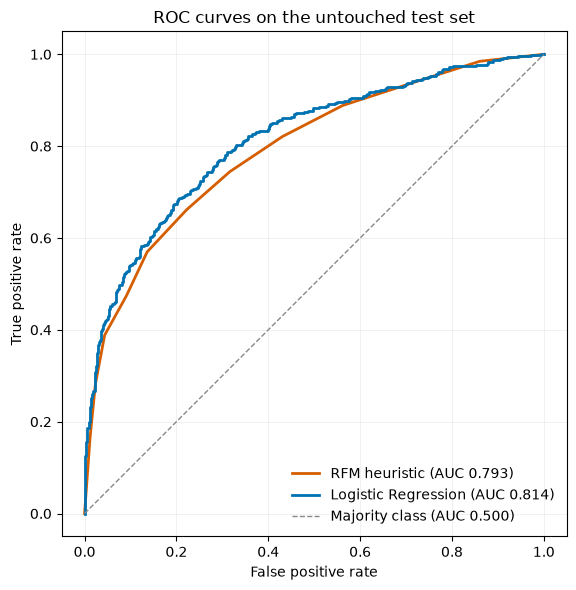

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(6, 6))

# Okabe-Ito colorblind-safe qualitative palette, fixed assignment per series.
COLOR_RFM = "#D55E00"       # vermillion
COLOR_LOGREG = "#0072B2"    # blue
COLOR_REFERENCE = "#888888"  # neutral gray, non-data reference line

fpr_rfm, tpr_rfm, _ = roc_curve(y_test, test_rfm_total)
fpr_lr, tpr_lr, _ = roc_curve(y_test, logreg_proba)

ax.plot(fpr_rfm, tpr_rfm, color=COLOR_RFM, linewidth=2,
        label=f"RFM heuristic (AUC {rfm_roc_auc:.3f})")
ax.plot(fpr_lr, tpr_lr, color=COLOR_LOGREG, linewidth=2,
        label=f"Logistic Regression (AUC {logreg_roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color=COLOR_REFERENCE, linewidth=1, linestyle="--",
        label="Majority class (AUC 0.500)")

ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves on the untouched test set")
ax.legend(loc="lower right", frameon=False)
ax.grid(True, alpha=0.25, linewidth=0.5)
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

Logistic Regression's curve sits at or above the RFM heuristic's across nearly the entire
range, not just on average. No crossing where the heuristic pulls ahead in some region and
falls behind in another, which would have been a more interesting and more cautionary
result than a single AUC number could show. The two curves run close together at very low
false-positive rate, which matches the near-flat difference in the bottom-left tail of the
comparison table.

## 6. Refactor the preprocessor into `src/`

`BINARY_COLUMNS` and `CONTINUOUS_COLUMNS` move to `src/config.py`, and the
`ColumnTransformer` construction moves to `src/modeling.py` as `build_preprocessor()`.
Stage 7 needs the exact same preprocessing for XGBoost and LightGBM (`each as
Pipeline(preprocessor, model) using the same preprocessor object type as the baseline`),
so this has to be importable now rather than copy-pasted into the next notebook.

Proving equivalence the same way Stage 5 did: rebuild the pipeline from the module,
refit, and confirm the predictions match the prototype exactly rather than trusting the
port.

In [13]:
import importlib

import src.config as config
import src.modeling as modeling

for mod in (config, modeling):
    importlib.reload(mod)

logger.info("config.CONTINUOUS_COLUMNS matches notebook: %s",
            config.CONTINUOUS_COLUMNS == CONTINUOUS_COLUMNS)
logger.info("config.BINARY_COLUMNS matches notebook: %s",
            config.BINARY_COLUMNS == BINARY_COLUMNS)

module_pipeline = Pipeline([
    ("preprocess", modeling.build_preprocessor()),
    ("model", LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)),
])
module_pipeline.fit(X_train, y_train)
module_proba = module_pipeline.predict_proba(X_test)[:, 1]

predictions_match = np.allclose(module_proba, logreg_proba)
logger.info("module pipeline predictions match prototype exactly: %s", predictions_match)
assert predictions_match, "src/modeling.py diverged from the notebook prototype"

19:43:15 | 04-split-baseline | INFO | config.CONTINUOUS_COLUMNS matches notebook: True


19:43:15 | 04-split-baseline | INFO | config.BINARY_COLUMNS matches notebook: True


19:43:15 | 04-split-baseline | INFO | module pipeline predictions match prototype exactly: True


Column lists match, and the refit pipeline's predictions are `np.allclose` to the
prototype's, exactly. `src/modeling.py` is a faithful port, not a rewrite.

## 7. Save the baseline artifact

Saving `module_pipeline`, the one built from `src/modeling.py`, not the inline prototype,
since that is the object every later stage should treat as canonical. Reload-and-verify
follows immediately: load it back from disk into a fresh variable and confirm its
predictions on test are identical to the pipeline still in memory.

In [14]:
import joblib

from src.config import MODELS_DIR

BASELINE_MODEL_PATH = MODELS_DIR / "baseline_logreg.joblib"
joblib.dump(module_pipeline, BASELINE_MODEL_PATH)
logger.info("wrote %s (%.1f KB)", BASELINE_MODEL_PATH.name, BASELINE_MODEL_PATH.stat().st_size / 1024)

reloaded_pipeline = joblib.load(BASELINE_MODEL_PATH)
reloaded_proba = reloaded_pipeline.predict_proba(X_test)[:, 1]

logger.info("reloaded predictions match in-memory pipeline exactly: %s",
            np.allclose(reloaded_proba, module_proba))
logger.info("reloaded ROC-AUC: %.4f (matches: %s)",
            roc_auc_score(y_test, reloaded_proba),
            abs(roc_auc_score(y_test, reloaded_proba) - logreg_roc_auc) < 1e-9)

19:43:15 | 04-split-baseline | INFO | wrote baseline_logreg.joblib (5.2 KB)


19:43:15 | 04-split-baseline | INFO | reloaded predictions match in-memory pipeline exactly: True


19:43:15 | 04-split-baseline | INFO | reloaded ROC-AUC: 0.8139 (matches: True)


5.2 KB, and the reloaded pipeline's predictions are bit-identical to the in-memory one:
same ROC-AUC, 0.8139. The scaler travels inside the pipeline, so nothing was left to load
separately or get out of sync.

## 8. Stage 6 summary

### What was produced

- `data/processed/train.parquet` (4,204 rows) and `test.parquet` (1,052 rows), split once,
  stratified, seed 42. Every later stage loads these files and never re-splits.
- `src/modeling.py`: `build_preprocessor()`, the `ColumnTransformer` every model in this
  project fits inside, from here through Stage 10.
- `src/config.py`: `BINARY_COLUMNS` (9) and `CONTINUOUS_COLUMNS` (22) now pinned.
- `models/baseline_logreg.joblib`: the fitted Logistic Regression pipeline.

### Key numbers

| Baseline | ROC-AUC | PR-AUC |
|---|---|---|
| Majority class | 0.5000 | 0.4354 |
| RFM heuristic | 0.7932 | 0.7443 |
| Logistic Regression | **0.8139** | **0.7962** |

Logistic Regression clears the Stage 0 floor (0.75) and beats the RFM heuristic by 0.0206
ROC-AUC on this split. Whether that gap survives cross-validation, the actual Stage 0 bar,
is Stage 7's question, not this notebook's.

### Decisions made here

1. The RFM heuristic's quintile edges are fit on **train only** and applied to test with
   `-inf`/`+inf`-extended cut points, correcting the EDA's whole-population computation,
   which would have leaked the test distribution into the incumbent baseline.
2. Scaling lives inside the pipeline (`ColumnTransformer` fit during `.fit(train)`), never
   outside it, so the test set never influences a scaler statistic.
3. **A real bug was found here, not in Stage 5**: `LogisticRegression.fit()` rejected the
   feature matrix with `Input X contains infinity`. Traced to `recency_over_avg_gap` for
   73 customers who placed multiple orders on the same calendar day, where
   `avg_days_between_orders` truncated to exactly 0. Fixed in `src/features.py` with a
   1.0-day floor (CLAUDE.md decision 5.8), and `build_customer_features` now asserts zero
   infinite values, not just zero nulls.
4. **Two of three coefficient sign predictions failed**, and the cause was confirmed, not
   assumed: `monetary_total` (-1.345) and `spend_last_365d` correlate at 0.96, and
   `is_single_order_customer` (+0.564) correlates 0.97 with `avg_days_between_orders`.
   Refitting on the correlated cluster alone reproduced the same sign instability,
   confirming multicollinearity rather than a real reversal of what any feature means.
   Predictive performance is unaffected; individual baseline coefficients are not a
   reliable "what drives repeat purchase" story until Stage 9's SHAP pass.

### Open questions for later stages

- Is the 0.0206 ROC-AUC gap over the RFM heuristic real or noise? Needs Stage 7's
  cross-validated fold standard deviations to answer, per Stage 0 decision 0.6.
- The collinear pairs (`monetary_total`/`spend_last_365d`,
  `is_single_order_customer`/`avg_days_between_orders`) do not need fixing for prediction,
  since tree models in Stage 7 are unaffected by collinearity. Worth deciding in Stage 9
  whether a cleaner interpretability pass drops one of each pair.

### Exit check

| Requirement | Status |
|---|---|
| Split files saved | Section 1 |
| Three baselines recorded | Sections 2-5 |
| Baseline artifact saved | Section 7 |
| Metrics clearly beat the trivial baseline | Section 5 (0.8139 vs 0.5000) |

Stage 7 may begin.